# Data Clustering Using Decision Tree Algorithm for Business Intelligence

This notebook demonstrates how to perform data clustering and then use a Decision Tree algorithm to extract business intelligence from the clusters.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## 2. Load and Explore the Data

Replace the file path with your business dataset as needed.

In [2]:
# Example: Load a sample dataset
from sklearn.datasets import load_iris

data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 3. Data Preprocessing

Check for missing values and scale features if necessary.

In [3]:
# Check for missing values
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

In [4]:
# Feature scaling (optional, depending on data)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

## 4. Clustering with KMeans

Cluster the data into groups for further analysis.

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df["Cluster"] = clusters
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,2
2,4.7,3.2,1.3,0.2,2
3,4.6,3.1,1.5,0.2,2
4,5.0,3.6,1.4,0.2,1


## 5. Analyze Clusters Using Decision Tree

Train a Decision Tree to understand the rules that define each cluster.

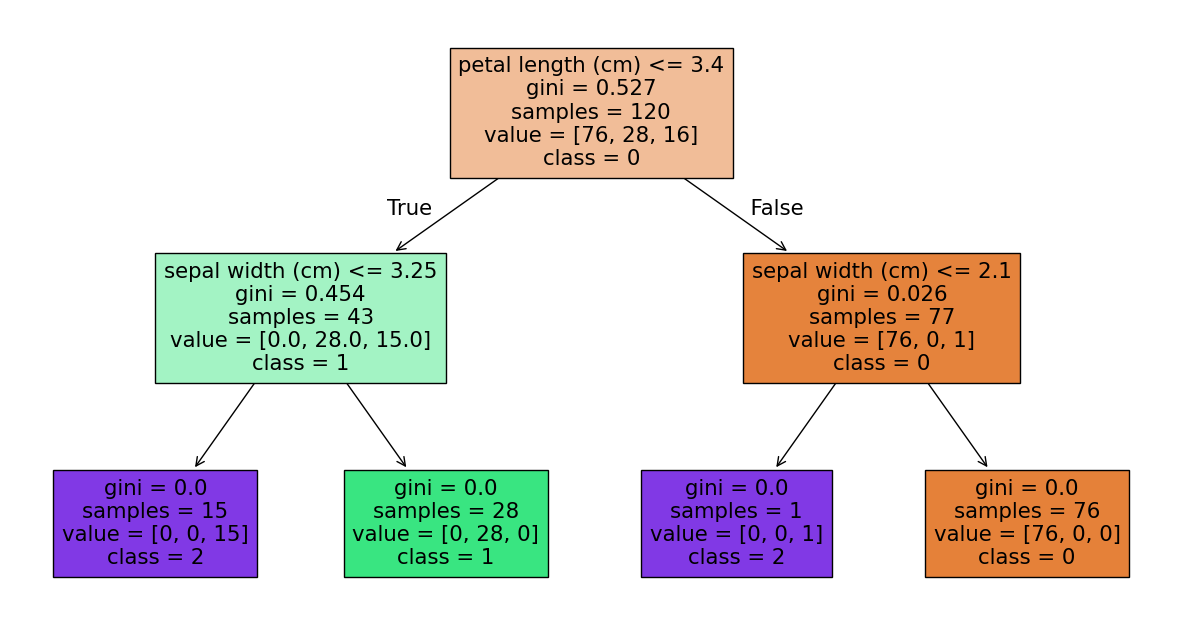

In [6]:
X = df.drop("Cluster", axis=1)
y = df["Cluster"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

dtree = DecisionTreeClassifier(max_depth=3, random_state=42)
dtree.fit(X_train, y_train)

plt.figure(figsize=(15, 8))
plot_tree(
    dtree,
    feature_names=X.columns,
    class_names=[str(i) for i in np.unique(y)],
    filled=True,
)
plt.show()

## 6. Business Intelligence Insights

Interpret the decision tree to extract actionable business insights from the clusters.